In [ ]:
import pandas as pd # enables manipulation of dataframes in Python
import numpy as np # enables manipulation of arrays in Python
import random # fetches random values
from urllib.request import urlretrieve # enables the downloading of files from the internet via URL
import gzip # module to enable I/O of gzipped files
import shutil # module to perform operations on files
from Bio import SeqIO # import the SeqIO Biopython module for working with sequence data
import matplotlib.pyplot as plt # import the matplotlib graphics module
import seaborn as sns # import the seaborn graphics module
import warnings # module to manage warnings
from scipy import stats
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
warnings.simplefilter(action='ignore', category=FutureWarning) # prevent Python from warning of future feature deprecation

This Notebook does not contain essential part of the project work. The following two cells were workarounds from the DEseq notebook but everything else was more of an exploratory data analysis and might not work anymore due to some missing files

In [ ]:
def c_h_e(row):
    return (row[1:]>10).sum() >= 4

In [ ]:
df2 = pd.read_csv("../HP_counts.txt", sep="\t")
df = pd.read_csv("../HP_counts_fixed_163_highexpression.txt", sep=",")

filter_data = df2[df2.apply(c_h_e, axis=1)]
#df.index = df2.index  # Manually set the index after reading both files
filter_data.to_csv("../HP_counts_fixed_163_highexpression_withrows")

From this point on the notebook is not important anymore and can be ignored!

In [8]:
df = pd.read_csv("../HP_counts_fixed_163.txt", sep="\t")
annot = pd.read_csv("../Annotations/HP26695.gtf", sep='\t', header=None, comment='#')
annot.columns = ['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute']
count_sum = df.sum(axis=1).sort_values(ascending=False)
count_sum

HP_r07     940133
HP_r04     561437
HP_r01     558502
HP_1432     30552
HP_0072     29684
            ...  
HP_0365         0
HP_0989         0
HP_t05          0
HP_t18          0
HP_t06          0
Length: 1609, dtype: int64

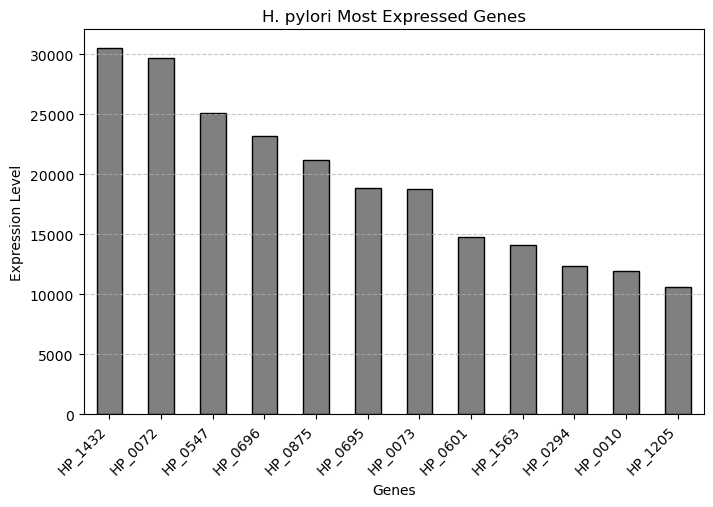

In [9]:
df_filtered = count_sum.iloc[3:15]

# Transpose for plotting
df_filtered = df_filtered.T
df_filtered.columns = ["Expression Level"]

# Plotting
plt.figure(figsize=(8,5))
df_filtered.plot(kind="bar", legend=False, color="gray", edgecolor="black")
plt.xlabel("Genes")
plt.ylabel("Expression Level")
plt.title("H. pylori Most Expressed Genes")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

In [95]:
raw_metadata = pd.read_csv("../Data/bacteria_counts_clean_highexpression.txt")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 51: invalid start byte

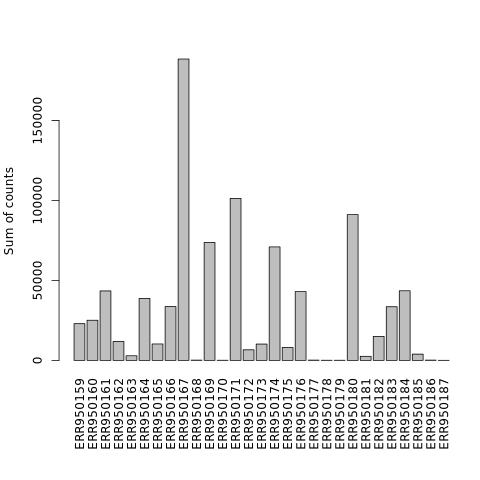

In [116]:
%%R
counts_data <- read.csv("../bacteria_counts_clean_highexpression.txt", row.names = 1)  # Ändere den Dateinamen entsprechend
metadata <- read.csv("../metadata_clean.txt", row.names = 1)
metadata$group <- gsub("[0-9]", "", metadata$library_name)
metadata$run_accession <- rownames(metadata)

rownames(counts_data) = counts_data$Geneid
counts_data = counts_data[,-1]
#summary(counts_data)

par(mar=c(8,4,4,1)+0.1)
barplot(colSums(counts_data), las=3, ylab= "Sum of counts")

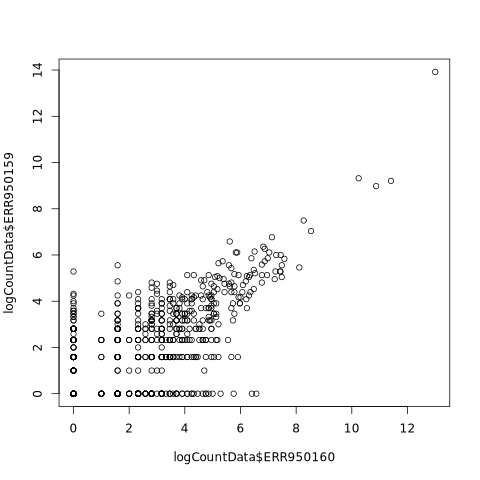

In [119]:
%%R
logCountData = log2(1+counts_data)
plot(logCountData$ERR950160, logCountData$ERR950159)

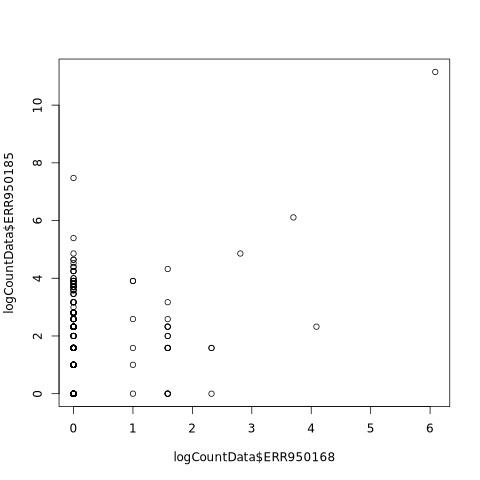

In [123]:
%%R
logCountData = log2(1+counts_data)
plot(logCountData$ERR950168, logCountData$ERR950185)

In [86]:
%%R
# Sicherstellen, dass Spaltennamen den run_accession entsprechen
colnames(counts_data) <- gsub("^X", "", colnames(counts_data))  # Falls Spaltennamen "X..." haben

# Summe der Counts pro Sample berechnen
sum_counts <- colSums(counts_data)

# Create dataframe with counts and groups
df <- data.frame(run_accession = names(sum_counts), SumCounts = sum_counts)
df <- merge(df, metadata, by = "run_accession", all.x = TRUE)

# Define the correct order of groups
group_order <- c("Hp", "Gast", "Atr", "EA", "Met")

# Convert 'group' column to a factor with the desired order
df$group <- factor(df$group, levels = group_order)

# Compute mean and standard deviation per group
group_means <- tapply(df$SumCounts, df$group, mean, na.rm = TRUE)
group_sd <- tapply(df$SumCounts, df$group, sd, na.rm = TRUE)

# Remove NA values (in case some groups are missing)
group_means <- group_means[!is.na(group_means)]
group_sd <- group_sd[!is.na(group_sd)]




R[write to console]: dev.new(): using pdf(file="Rplots1.pdf")



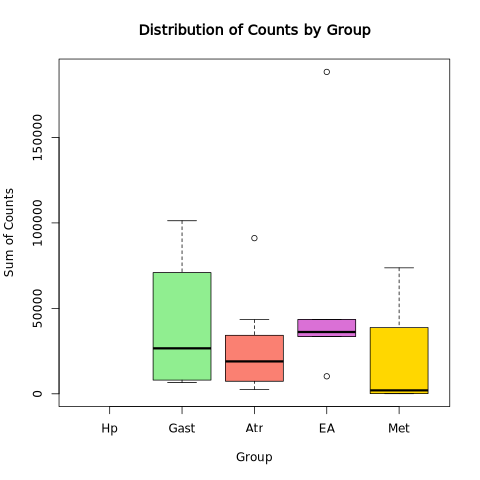

In [87]:
%%R
# Boxplot: Variability within groups
boxplot(SumCounts ~ group, data = df, 
        col = c("lightblue", "lightgreen", "salmon", "orchid", "gold"), 
        main = "Distribution of Counts by Group",
        xlab = "Group", 
        ylab = "Sum of Counts",
        border = "black")


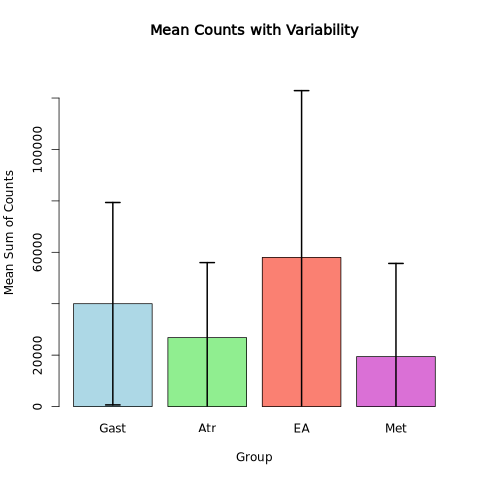

In [89]:
%%R
# Barplot with Error Bars: Mean + SD per group
bar_x <- barplot(group_means, 
                 col = c("lightblue", "lightgreen", "salmon", "orchid", "gold"), 
                 ylim = c(0, max(group_means + group_sd) * 1.1), 
                 main = "Mean Counts with Variability", 
                 xlab = "Group", 
                 ylab = "Mean Sum of Counts", 
                 border = "black")

# Add error bars (Standard Deviation)
arrows(bar_x, group_means - group_sd, bar_x, group_means + group_sd, 
       angle = 90, code = 3, length = 0.1, col = "black", lwd = 2)


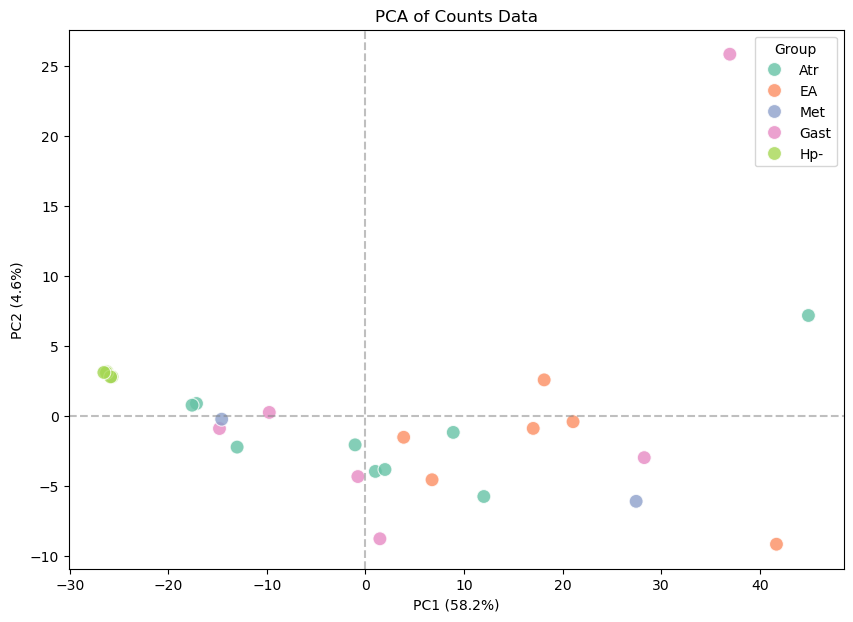

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

counts_data_raw = pd.read_csv("../bacteria_counts_clean_highexpression.txt", index_col=0)
metadata = pd.read_csv("../metadata_clean.txt", index_col=0)

counts_data = counts_data_raw.loc[:, counts_data_raw.sum() != 0]

counts_data = counts_data.apply(pd.to_numeric, errors="coerce")

counts_data_log = np.log1p(counts_data)  # log1p(x) = log(1 + x)

scaler = StandardScaler()
counts_scaled = scaler.fit_transform(counts_data_log.T)  

pca = PCA(n_components=2)  
pca_results = pca.fit_transform(counts_scaled)

pca_df = pd.DataFrame(pca_results, columns=["PC1", "PC2"], index=counts_data.columns)

metadata["group"] = metadata["library_name"].str.replace(r"\d+", "", regex=True)  # Extrahiert Gruppenbuchstaben
pca_df["group"] = metadata.loc[pca_df.index, "group"]

plt.figure(figsize=(10, 7))
sns.scatterplot(x="PC1", y="PC2", hue="group", data=pca_df, palette="Set2", s=100, alpha=0.8)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of Counts Data")
plt.legend(title="Group")
plt.axhline(0, linestyle="dashed", color="gray", alpha=0.5)
plt.axvline(0, linestyle="dashed", color="gray", alpha=0.5)
plt.show()
plt.savefig("PCAstages.png")


In [111]:
counts_data.head()

,ERR950158,ERR950159,ERR950160,ERR950161,ERR950162,ERR950163,ERR950164,ERR950165,ERR950166,ERR950167,...,ERR950178,ERR950179,ERR950180,ERR950181,ERR950182,ERR950183,ERR950184,ERR950185,ERR950186,ERR950187
Geneid,,,,,,,,,,,,,,,,,,,,,
HP_0573,4,5,8,7,0,2,17,1,13,4,...,0,0,18,0,2,0,5,2,0,0
HP_0020,12,6,5,10,14,0,23,2,2,19,...,0,0,18,2,5,6,5,6,0,0
HP_1325,10,9,28,12,16,3,18,6,26,85,...,0,0,65,2,14,6,12,4,0,0
HP_0038,2,0,0,0,0,0,2,0,0,2,...,0,0,17,2,0,0,0,0,0,0
HP_0493,2,0,0,2,0,0,10,8,6,6,...,0,0,16,0,2,0,4,4,0,0


In [27]:
counts_melted = counts_df.melt(id_vars=["Geneid"], var_name="run_accession", value_name="counts")
df = counts_melted.merge(metadata, on="run_accession")
df = df[df["Geneid"].str.startswith("H")]
df["stage"] = df["library_name"].str.extract(r'([A-Za-z]+)')
df

,Geneid,run_accession,counts,library_name,stage
0,HP_0573,ERR950158,4,Atr1,Atr
1,HP_0020,ERR950158,12,Atr1,Atr
2,HP_1325,ERR950158,10,Atr1,Atr
3,HP_0038,ERR950158,2,Atr1,Atr
4,HP_0765,ERR950158,0,Atr1,Atr
...,...,...,...,...,...
2337293,HP_t07,ERR950187,0,Hp-4,Hp
2337294,HP_t08,ERR950187,0,Hp-4,Hp
2337295,HP_r07,ERR950187,18,Hp-4,Hp
2337296,HP_t12,ERR950187,0,Hp-4,Hp


In [39]:
gene_variances = df.groupby(["Geneid", "stage"])["counts"].var().reset_index()
gene_variances

,Geneid,stage,counts
0,HP_0001,Atr,6.111111
1,HP_0001,EA,2.400000
2,HP_0001,Gast,15.600000
3,HP_0001,Hp,0.000000
4,HP_0001,Met,9.000000
...,...,...,...
8040,HP_t36,Atr,1.250000
8041,HP_t36,EA,0.666667
8042,HP_t36,Gast,0.000000
8043,HP_t36,Hp,0.000000


: 

FileNotFoundError: [Errno 2] No such file or directory: '../../metadata_clean.txt'